# **NN**

 **Redes Neurais - mas afinal, o que são neuronios artificiais e redes neurais aritificias?**

Uma rede neural artificial é um modelo computacional inspirado no funcionamento do cérebro humano.

Mas o que é um neurônio artificial?

Um neurônio artificial é a unidade fundamental de uma rede neural artificial, inspirada no funcionamento dos neurônios biológicos do cérebro humano.

Ele é uma FUNÇÃO MATEMÁTICA que recebe entradas, realiza cálculos e gera uma saída, que pode ser usada por outros neurônios da rede, de forma análoga, e simplificada, de um neurônio biológico.

Também são conhecidos como perceptrons.

Então, ***uma rede neural artificial é um conjunto estruturado de funções.***

**Antes do exemplo: como pensar em um neurônio artificial**

Antes de montar uma rede neural, vale entender a menor unidade dela: o neurônio artificial.

Um neurônio artificial recebe entradas numéricas, combina essas entradas e produz uma saída.

- **Entradas**: informações que descrevem o problema.
- **Pesos**: indicam o quanto cada entrada influencia o resultado.
- **Saída**: o valor final produzido pelo neurônio.

Em outras palavras, o neurônio artificial funciona como uma pequena regra matemática que transforma informações de entrada em uma resposta.

Primeiro vamos ver isso em um exemplo simples. Depois ampliaremos a ideia para uma rede neural com mais de um neurônio.

**1. Definição do Problema**
Antes de olhar para os valores do exemplo, precisamos entender de onde surgem os pesos.

Os pesos são valores numéricos associados a cada entrada do neurônio artificial.

- Um peso maior significa maior influência no resultado.
- Um peso positivo aumenta a saída.
- Um peso negativo reduz a saída.

Neste primeiro momento, vamos usar **pesos hipotéticos**, escolhidos apenas para entender o cálculo passo a passo.

Em uma rede neural real, esses pesos são ajustados automaticamente durante o treinamento, a partir dos exemplos vistos pela rede e dos erros cometidos ao tentar prever a resposta correta.

Agora sim, vamos ao exemplo.

Suponha que queremos prever se um e-mail é spam (1) ou não é spam (0) com base em:

- Quantidade de links no e-mail (escala de 0 a 10, onde 10 = muitos links).
- Presença de linguagem suspeita (escala de 0 a 10, onde 10 = muitas palavras ou expressoes suspeitas).
- Confiabilidade do remetente (escala de 0 a 10, onde 10 = remetente muito confiavel).

**1.1. Exemplo de um unico neuronio artificial**

Antes de pensar em uma rede neural inteira, vale isolar apenas um neurônio artificial.

A ideia aqui é enxergar a lógica mais simples possível: o neurônio recebe algumas informações de entrada, atribui importâncias diferentes a elas e produz um valor de saída.

Se essa lógica ficar clara em um único neurônio, depois fica muito mais fácil entender o que acontece quando vários neurônios são organizados em camadas, formando uma rede neural.

Uma forma simples de representar matematicamente um neurônio artificial é:

**saida = (peso1 x entrada1) + (peso2 x entrada2) + (peso3 x entrada3) + vies**

Ou, de forma mais compacta:

**y = w1x1 + w2x2 + w3x3 + b**

Onde:

- `x1`, `x2`, `x3` são as entradas.
- `w1`, `w2`, `w3` são os pesos.
- `b` é o viés (bias), um ajuste adicional no cálculo.
- `y` é o resultado produzido pelo neurônio.

Nesse cálculo, cada entrada é multiplicada por sua importância relativa, e depois tudo é somado.

Vamos ver isso com números simples antes de passar para a rede neural completa.

In [1]:
# Exemplo didatico de um unico neuronio artificial
# Formula: y = w1*x1 + w2*x2 + w3*x3 + b
# Aqui vamos usar pesos coerentes com o padrao observado na base rotulada:
# links e linguagem suspeita empurram a saida para spam,
# enquanto confiabilidade do remetente empurra para nao spam.

# Entradas
x1 = 8.0   # quantidade de links
x2 = 7.0   # linguagem suspeita
x3 = 2.0   # confiabilidade do remetente

# Pesos coerentes com o padrao da base rotulada
w1 = 0.62   # muitos links aumentam a pontuacao de suspeita
w2 = 0.64   # linguagem suspeita aumenta a pontuacao de suspeita
w3 = -0.66  # remetente confiavel reduz a pontuacao de suspeita

# Vies (bias)
# Este valor desloca a funcao para separar melhor casos mais parecidos com spam
# de casos mais parecidos com nao spam.
b = -2.24

y = w1*x1 + w2*x2 + w3*x3 + b

print(f'Resultado do neuronio: {y:.2f}')
print('Interpretacao: quanto maior esse valor, maior a pontuacao de suspeita do e-mail.')

Resultado do neuronio: 5.88
Interpretacao: quanto maior esse valor, maior a pontuacao de suspeita do e-mail.


**1.2. Contextualizando o exemplo na pratica**

Vamos imaginar um problema real: identificar se um e-mail deve ou nao ir para a caixa de spam.

Esse tipo de decisao pode ser representado por um neurônio artificial porque queremos combinar alguns sinais observados no e-mail e gerar um resultado final.

Para montar esse exemplo, primeiro escolhemos **quais informacoes do e-mail vamos observar**. Aqui, vamos usar tres sinais simples:

- **Quantidade de links**: e-mails com muitos links podem ser mais suspeitos.
- **Linguagem suspeita**: expressoes como "clique agora", "oferta imperdivel" ou "urgente" podem aumentar a suspeita.
- **Confiabilidade do remetente**: um remetente conhecido e confiavel tende a reduzir a chance de spam.

**Passo 2: transformar cada criterio em uma escala numerica**

Depois de escolher os tres criterios, precisamos definir **como cada um deles sera medido em numeros**. Para isso, podemos criar uma pequena tabela ou regra de pontuacao para cada criterio, sempre em uma escala de 0 a 10.

**Tabela 1: quantidade de links**

| Situacao observada | Pontuacao |
|---|---:|
| Nenhum link | 0 |
| 1 a 2 links | 3 |
| 3 a 5 links | 6 |
| Mais de 5 links | 8 a 10 |

**Tabela 2: linguagem suspeita**

| Situacao observada | Pontuacao |
|---|---:|
| Nenhuma expressao suspeita | 0 |
| Poucas expressoes suspeitas | 3 |
| Varias expressoes suspeitas | 7 |
| Linguagem fortemente apelativa ou urgente | 8 a 10 |

**Tabela 3: confiabilidade do remetente**

| Situacao observada | Pontuacao |
|---|---:|
| Remetente desconhecido ou estranho | 0 a 2 |
| Remetente pouco familiar | 3 a 5 |
| Remetente conhecido | 6 a 8 |
| Remetente altamente confiavel | 9 a 10 |

Isso e importante porque o neurônio artificial trabalha com numeros, e nao diretamente com texto.

Vale reforcar um ponto importante: **essas tabelas nao sao o neurônio artificial**. Elas sao apenas uma forma didatica de transformar observacoes do mundo real em valores numericos que depois poderao ser usados como entrada da funcao.

**Passo 3: pegar um e-mail real e montar seu vetor de entrada**

Agora escolhemos um e-mail especifico e avaliamos esse e-mail usando as tres tabelas acima.

Suponha o seguinte caso:

- o e-mail tem muitos links no corpo da mensagem;
- o texto usa expressoes como "clique agora" e "oferta imperdivel";
- o remetente parece pouco confiavel ou desconhecido.

Ao relacionar esse e-mail com as tabelas, podemos atribuir os seguintes valores:

- `x1 = 8.0`: muitos links.
- `x2 = 7.0`: varias expressoes suspeitas.
- `x3 = 2.0`: remetente pouco confiavel.

Assim, o vetor que representa esse e-mail fica:

`x = [8.0, 7.0, 2.0]`

Esse vetor resume, em forma numerica, o e-mail que estamos avaliando.

**Passo 4: parametrizar a funcao**

Agora chegamos ao ponto central: o neurônio artificial e a **funcao matematica** que combina as entradas do vetor com pesos e vies. Ou seja, o neurônio nao e uma tabelinha, nem um conjunto de matrizes soltas; ele e uma regra matematica parametrizada.

Em seguida, definimos os **pesos** e o **vies** da funcao. Neste exemplo didatico, esses parametros ainda nao foram aprendidos por treinamento; estamos escolhendo valores manualmente apenas para representar a ideia de importancia de cada sinal:

- Um peso **positivo** aumenta a chance de o e-mail ser classificado como spam.
- Um peso **negativo** reduz essa chance.
- Um peso com valor absoluto maior indica maior influencia no resultado.

Por isso, faz sentido que:

- muitos links tenham peso positivo;
- linguagem suspeita tambem tenha peso positivo;
- confiabilidade do remetente tenha peso negativo.

**Observacao: como isso funcionaria na pratica?**

Em um sistema real, esses parametros podem ser **aprendidos a partir de uma base rotulada**. Por exemplo, podemos separar um subconjunto de e-mails que ja foi classificado por humanos como `spam` ou `nao spam`. A partir desses exemplos rotulados, o modelo ajusta os pesos para que a funcao produza saidas coerentes com essas classificacoes.

Em uma aplicacao real, o processo seria mais ou menos assim:

1. reunimos um conjunto grande de e-mails que ja foram rotulados por humanos como `spam` ou `nao spam`;
2. para cada e-mail, extraimos os valores das caracteristicas escolhidas, formando vetores numericos;
3. usamos esses vetores e seus rotulos para ajustar os pesos e o vies da funcao;
4. depois do treinamento, apresentamos um novo e-mail ao modelo;
5. o neurônio calcula uma pontuacao com base nos pesos aprendidos;
6. essa pontuacao indica o quanto o novo e-mail se parece, em termos de padrao, com os exemplos que o modelo aprendeu como spam ou nao spam.

Portanto, a grande ideia do neurônio artificial nao e montar tabelas manualmente, e sim ter uma funcao cujos parametros podem ser ajustados com dados e depois usados para avaliar novos casos semelhantes.

Com isso, podemos montar o calculo do neurônio:

`y = w1x1 + w2x2 + w3x3 + b`

Usando os mesmos valores ja calculados no exemplo de codigo acima:

- `w1 = 0.62`
- `w2 = 0.64`
- `w3 = -0.66`
- `b = -2.24`

Substituindo na formula:

`y = (0.62 x 8.0) + (0.64 x 7.0) + (-0.66 x 2.0) + (-2.24)`

`y = 4.96 + 4.48 - 1.32 - 2.24 = 5.88`

Esse resultado final funciona como uma pontuacao: quanto maior, maior a tendencia de o e-mail ser spam.

Neste ponto, ainda e mais correto interpretar `y = 5.88` como uma **pontuacao de suspeita** do que como uma decisao final fechada.

Ou seja: esse valor sugere que o e-mail apresenta varios sinais compativeis com spam. Em uma aplicacao real, essa pontuacao ainda poderia passar por uma regra de decisao, por uma funcao de ativacao ou por outras camadas da rede antes da classificacao final.

Mesmo assim, para fins intuitivos, podemos dizer que **o neurônio atribuiu a esse e-mail uma suspeita alta de spam**.

Ou seja, o objetivo pratico deste exemplo e mostrar o caminho completo:

1. observar caracteristicas do e-mail;
2. transformar essas caracteristicas em numeros;
3. montar o vetor numerico de um e-mail especifico;
4. parametrizar a funcao com pesos e vies;
5. combinar entradas e parametros em uma funcao matematica;
6. obter uma pontuacao final que apoia a decisao do modelo.

Agora que o problema esta contextualizado, podemos escrever essa logica na forma de uma funcao matematica.

**1.3. Como os pesos seriam criados na pratica?**

Ate aqui, usamos pesos hipoteticos apenas para entender a ideia da funcao. Mas, em uma aplicacao real, esses pesos nao precisam ser escolhidos manualmente.

Uma forma de pensar nisso e imaginar uma pequena base rotulada com 10 e-mails, ja classificados por humanos como `spam` ou `nao spam`.

| E-mail | Links | Linguagem suspeita | Confiabilidade do remetente | Rotulo humano |
|---|---:|---:|---:|---|
| 1 | 9 | 8 | 1 | spam |
| 2 | 8 | 7 | 2 | spam |
| 3 | 7 | 9 | 1 | spam |
| 4 | 6 | 8 | 2 | spam |
| 5 | 8 | 6 | 3 | spam |
| 6 | 1 | 1 | 9 | nao spam |
| 7 | 2 | 2 | 8 | nao spam |
| 8 | 0 | 1 | 10 | nao spam |
| 9 | 3 | 2 | 7 | nao spam |
| 10 | 1 | 0 | 8 | nao spam |

Observe o padrao geral dessa base:

- nos e-mails rotulados como `spam`, tende a haver mais links, mais linguagem suspeita e menor confiabilidade do remetente;
- nos e-mails rotulados como `nao spam`, tende a haver poucos links, pouca linguagem suspeita e remetentes mais confiaveis.

O treinamento da rede tenta encontrar pesos que reproduzam esse padrao.

Em termos intuitivos, o processo funciona assim:

1. apresentamos ao modelo os vetores dos 10 e-mails;
2. o neurônio calcula uma saida inicial com pesos aleatorios ou muito simples;
3. essa saida e comparada com o rotulo humano correto;
4. quando o modelo erra, os pesos sao ajustados um pouco;
5. esse processo se repete muitas vezes, ate que a funcao fique mais coerente com os exemplos rotulados.

Depois de varias iteracoes, o modelo tende a aprender algo como:

- **peso positivo para links**: porque muitos links aparecem com frequencia em e-mails de spam;
- **peso positivo para linguagem suspeita**: porque esse sinal tambem aparece mais em spam;
- **peso negativo para confiabilidade do remetente**: porque remetentes confiaveis aparecem mais em e-mails nao spam.

Ou seja, os pesos nao surgem do nada. Eles sao ajustados a partir da relacao entre os vetores de entrada e os rotulos humanos da base de treinamento.

Depois que esses pesos sao aprendidos, podemos pegar um novo e-mail, montar seu vetor de entrada e pedir ao neurônio que calcule uma pontuacao de suspeita com base no padrao que ele aprendeu.

In [2]:
# Exemplo didatico: um unico neuronio ajustando pesos a partir de 10 e-mails rotulados
# A ideia aqui nao e reproduzir todo o treinamento moderno de redes neurais,
# mas mostrar intuitivamente como os pesos podem ser ajustados com base no erro.

import numpy as np

# Cada linha representa um e-mail: [links, linguagem_suspeita, confiabilidade_remetente]
X = np.array([
    [9, 8, 1],
    [8, 7, 2],
    [7, 9, 1],
    [6, 8, 2],
    [8, 6, 3],
    [1, 1, 9],
    [2, 2, 8],
    [0, 1, 10],
    [3, 2, 7],
    [1, 0, 8]
], dtype=float)

# Rotulos humanos: 1 = spam, 0 = nao spam
y = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0], dtype=float)

# Comecamos com pesos e vies zerados so para enxergar o ajuste acontecendo
weights = np.zeros(3)
bias = 0.0
learning_rate = 0.1

print('Pesos iniciais:', weights, 'Bias inicial:', bias)
print()
print('Ajuste linha a linha:')

for i, (x_i, y_real) in enumerate(zip(X, y), start=1):
    score = np.dot(x_i, weights) + bias
    y_pred = 1.0 if score >= 0 else 0.0
    error = y_real - y_pred

    # Regra simples de ajuste: quando ha erro, movemos pesos e bias um pouco
    weights = weights + learning_rate * error * x_i
    bias = bias + learning_rate * error

    print(f'E-mail {i}: entrada={x_i}, rotulo={int(y_real)}, score={score:.2f}, previsao={int(y_pred)}, erro={int(error)}')
    print(f'  Novos pesos: {weights}, novo bias: {bias:.2f}')

print() 
print('Pesos finais aprendidos neste exemplo simplificado:', weights)
print('Bias final:', round(bias, 2))
print('Interpretacao: links e linguagem suspeita tendem a empurrar a saida para spam, enquanto remetente confiavel tende a empurrar para nao spam.')

Pesos iniciais: [0. 0. 0.] Bias inicial: 0.0

Ajuste linha a linha:
E-mail 1: entrada=[9. 8. 1.], rotulo=1, score=0.00, previsao=1, erro=0
  Novos pesos: [0. 0. 0.], novo bias: 0.00
E-mail 2: entrada=[8. 7. 2.], rotulo=1, score=0.00, previsao=1, erro=0
  Novos pesos: [0. 0. 0.], novo bias: 0.00
E-mail 3: entrada=[7. 9. 1.], rotulo=1, score=0.00, previsao=1, erro=0
  Novos pesos: [0. 0. 0.], novo bias: 0.00
E-mail 4: entrada=[6. 8. 2.], rotulo=1, score=0.00, previsao=1, erro=0
  Novos pesos: [0. 0. 0.], novo bias: 0.00
E-mail 5: entrada=[8. 6. 3.], rotulo=1, score=0.00, previsao=1, erro=0
  Novos pesos: [0. 0. 0.], novo bias: 0.00
E-mail 6: entrada=[1. 1. 9.], rotulo=0, score=0.00, previsao=1, erro=-1
  Novos pesos: [-0.1 -0.1 -0.9], novo bias: -0.10
E-mail 7: entrada=[2. 2. 8.], rotulo=0, score=-7.70, previsao=0, erro=0
  Novos pesos: [-0.1 -0.1 -0.9], novo bias: -0.10
E-mail 8: entrada=[ 0.  1. 10.], rotulo=0, score=-9.20, previsao=0, erro=0
  Novos pesos: [-0.1 -0.1 -0.9], novo bias:

In [3]:
# Fechando o item 1: retomando o exemplo simples de um unico neuronio
# Depois de entender as entradas e como os pesos podem ser ajustados,
# podemos voltar ao nosso e-mail de exemplo e aplicar a funcao completa.

x1 = 8.0   # quantidade de links
x2 = 7.0   # linguagem suspeita
x3 = 2.0   # confiabilidade do remetente

w1 = 0.62
w2 = 0.64
w3 = -0.66
b = -2.24

y = w1*x1 + w2*x2 + w3*x3 + b

print('Retomando o e-mail de exemplo:')
print(f'Vetor de entrada: [{x1}, {x2}, {x3}]')
print(f'Calculo: ({w1}*{x1}) + ({w2}*{x2}) + ({w3}*{x3}) + ({b})')
print(f'Resultado final do neuronio: {y:.2f}')
print('Interpretacao: esse valor representa uma pontuacao de suspeita; quanto maior, maior a tendencia de o e-mail se parecer com os casos de spam vistos no treinamento.')

Retomando o e-mail de exemplo:
Vetor de entrada: [8.0, 7.0, 2.0]
Calculo: (0.62*8.0) + (0.64*7.0) + (-0.66*2.0) + (-2.24)
Resultado final do neuronio: 5.88
Interpretacao: esse valor representa uma pontuacao de suspeita; quanto maior, maior a tendencia de o e-mail se parecer com os casos de spam vistos no treinamento.


**2. Arquitetura da Rede Neural**

Agora vamos ampliar a ideia do neurônio isolado para uma **rede neural pequena**, mas mantendo exatamente o mesmo problema: avaliar se um e-mail apresenta sinais de spam.

A diferença é que, em vez de uma única função produzir a pontuação final diretamente, teremos **várias funções trabalhando em sequência**. Ex.: Camada de Entrada → Função/Camada Oculta (3 funções) → Função/Camada de Saída.

Vamos usar a seguinte estrutura:

- **Camada de entrada**: recebe os 3 valores do e-mail (`links`, `linguagem suspeita`, `confiabilidade do remetente`).
- **Camada oculta**: 3 neurônios intermediários, cada um combinando essas entradas de um jeito diferente.
- **Camada de saída**: 1 neurônio final, responsável por transformar o processamento anterior em uma pontuação final.

Isso não é aleatório: cada neurônio da camada oculta tem seu próprio conjunto de pesos (veja a matriz `weights_hidden` logo abaixo) e, por isso, "enxerga" o e-mail por um ângulo diferente. Olhando para os pesos que usaremos neste exemplo:

- **Neurônio oculto 1** pondera links e linguagem suspeita de forma parecida (0.3 e 0.4) e reage fortemente a remetentes pouco confiáveis (peso -0.4).
- **Neurônio oculto 2** é o mais sensível à confiabilidade do remetente (peso -0.5), dando menos peso a links e linguagem suspeita.
- **Neurônio oculto 3** é o que mais reage à linguagem suspeita (peso 0.5), e quase ignora a confiabilidade do remetente (peso -0.2, o mais fraco dos três).

Ou seja: em vez de fazer uma única pergunta — "esse e-mail parece spam?" —, a rede faz três leituras parciais e complementares do mesmo e-mail, e só depois combina essas leituras na camada de saída para chegar ao resultado final.

Neste exemplo, usaremos:

- **Camada de entrada** com 3 valores.
- **Camada oculta** com 3 neurônios e ativação ReLU.
- **Camada de saída** com 1 neurônio e ativação sigmoid, para gerar uma saída entre 0 e 1.

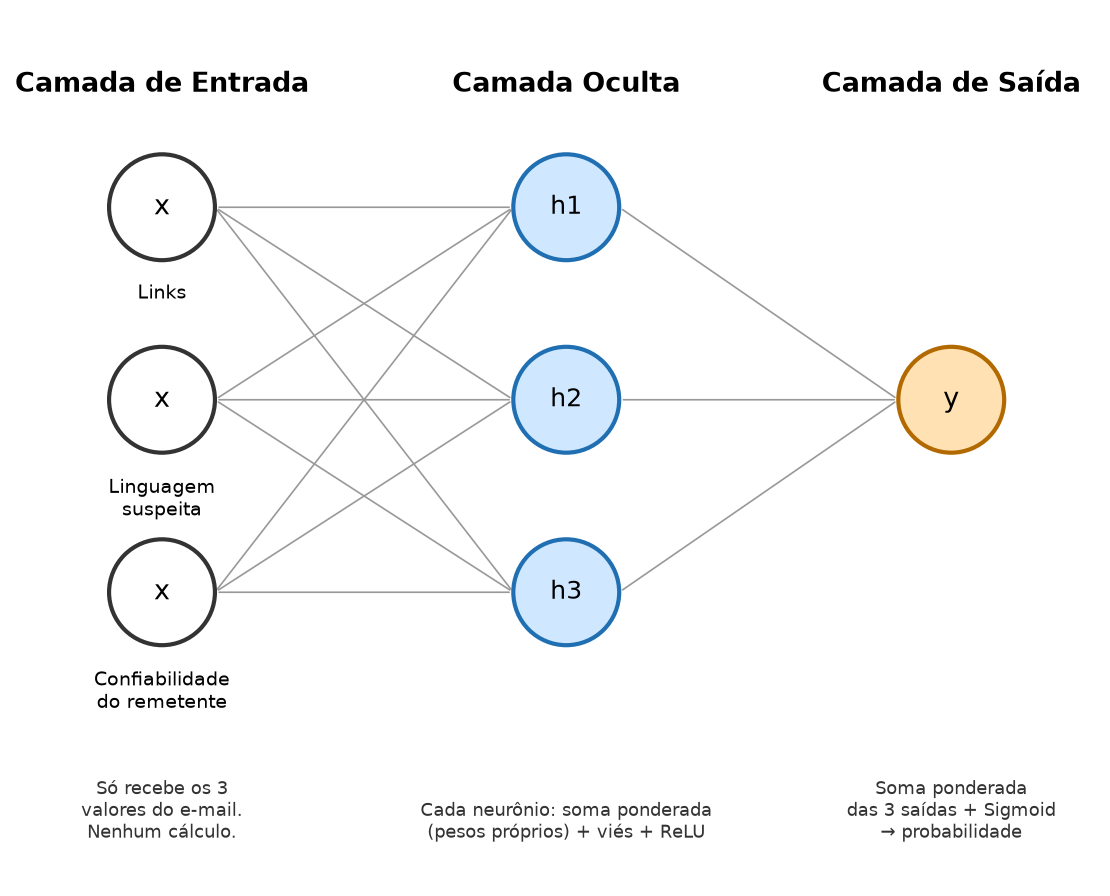

In [4]:
import numpy as np

# Vamos reutilizar o mesmo e-mail de exemplo
inputs = np.array([8.0, 7.0, 2.0])  # [links, linguagem_suspeita, confiabilidade_remetente]

# Pesos da camada oculta (3 entradas x 3 neuronios ocultos)
# Cada coluna mostra como um neuronio oculto combina os tres sinais do e-mail.
weights_hidden = np.array([
    [0.3, 0.2, 0.1],   # influencia de links
    [0.4, 0.3, 0.5],   # influencia de linguagem suspeita
    [-0.4, -0.5, -0.2] # influencia da confiabilidade do remetente
])

# Pesos do neuronio de saida
weights_output = np.array([0.2, 0.05, 0.15])

print('Vetor de entrada do e-mail:', inputs)
print('Pesos da camada oculta:')
print(weights_hidden)
print('Pesos da camada de saida:', weights_output)

Vetor de entrada do e-mail: [8. 7. 2.]
Pesos da camada oculta:
[[ 0.3  0.2  0.1]
 [ 0.4  0.3  0.5]
 [-0.4 -0.5 -0.2]]
Pesos da camada de saida: [0.2  0.05 0.15]


**3. Passo a Passo do Cálculo**

Vamos seguir o fluxo da rede em duas etapas: primeiro a camada oculta, depois a camada de saída.

a. **Primeira etapa: camada oculta**
- Cada neurônio oculto combina os 3 valores de entrada com pesos diferentes.
- Em seguida, aplicamos a ReLU para eliminar valores negativos.

In [5]:
import numpy as np

# Garante que o item 3 rode mesmo se o notebook tiver sido reiniciado
if 'inputs' not in globals():
    inputs = np.array([8.0, 7.0, 2.0])
    weights_hidden = np.array([
        [0.3, 0.2, 0.1],
        [0.4, 0.3, 0.5],
        [-0.4, -0.5, -0.2]
    ])
    weights_output = np.array([0.2, 0.05, 0.15])

print('1. Valores de entrada do e-mail:', inputs)
print('2. Matriz de pesos da camada oculta:', weights_hidden)
print('3. Vetor de pesos do neuronio de saida:', weights_output)

1. Valores de entrada do e-mail: [8. 7. 2.]
2. Matriz de pesos da camada oculta: [[ 0.3  0.2  0.1]
 [ 0.4  0.3  0.5]
 [-0.4 -0.5 -0.2]]
3. Vetor de pesos do neuronio de saida: [0.2  0.05 0.15]


In [6]:
## Primeira etapa de processamento
# a.1. Multiplicacao do vetor de entrada pelos pesos da camada oculta
# Parte linear da funcao
hidden_raw = np.dot(inputs, weights_hidden)
# Conferindo a conta manualmente:
# Neuronio oculto 1: 8*0.3 + 7*0.4 + 2*(-0.4) = 2.4 + 2.8 - 0.8 = 4.4
# Neuronio oculto 2: 8*0.2 + 7*0.3 + 2*(-0.5) = 1.6 + 2.1 - 1.0 = 2.7
# Neuronio oculto 3: 8*0.1 + 7*0.5 + 2*(-0.2) = 0.8 + 3.5 - 0.4 = 3.9
print('a.1. Resultado linear da camada oculta (antes da ReLU):', hidden_raw)

# a.2. Aplicar ReLU
# Parte nao linear da funcao
hidden_layer = np.maximum(0, hidden_raw)
print('a.2. Saida da camada oculta (depois da ReLU):', hidden_layer)

a.1. Resultado linear da camada oculta (antes da ReLU): [4.4 2.7 3.9]
a.2. Saida da camada oculta (depois da ReLU): [4.4 2.7 3.9]


b. **Segunda etapa: camada de saída**

- O neurônio de saída combina os resultados da camada oculta.
- Depois, a sigmoid transforma esse resultado em um valor entre 0 e 1.

In [7]:
# Recapitulando antes da segunda etapa
print('Saida da camada oculta (entrada para a camada de saida):', hidden_layer)
print('Vetor de pesos do neuronio de saida:', weights_output)

Saida da camada oculta (entrada para a camada de saida): [4.4 2.7 3.9]
Vetor de pesos do neuronio de saida: [0.2  0.05 0.15]


In [8]:
# Multiplicacao dos resultados da camada oculta pelo vetor de pesos do neuronio de saida
output_raw = np.dot(hidden_layer, weights_output)
# Calculo: 4.4*0.2 + 2.7*0.05 + 3.9*0.15 = 0.88 + 0.135 + 0.585 = 1.6
print('Resultado linear da camada de saida:', output_raw)

# Aplicar sigmoid (transformar em uma saida entre 0 e 1)
output = 1 / (1 + np.exp(-output_raw))
print(f'4. Probabilidade de spam: {output:.2f}')

Resultado linear da camada de saida: 1.6
4. Probabilidade de spam: 0.83


**4. Interpretacao do Resultado**

- Saida: aproximadamente `0.83`.
- Isso significa que, para esta rede pequena, o e-mail apresenta **alta probabilidade de ser spam**.

**Por que o valor ficou alto?**
- O e-mail tem muitos links e bastante linguagem suspeita.
- A confiabilidade do remetente e baixa, entao ela nao compensa os outros sinais.
- Os tres neuronios ocultos produziram ativacoes positivas, reforcando a suspeita na camada de saida.

**5. Diagrama Visual**

```
Input Layer (3 características)              Hidden Layer (3 neurônios)        Output Layer (1 neurônio)
          ┌───────────────────────────────┐        ┌───────────────────────────────┐       ┌──────────────────────┐
          │                               │        │                               │       │                      │
Links  →  │             8.0               │───┐    │        ReLU(4.4) = 4.4        │───┐   │                      │
          │                               │   │    │                               │   │   │      Sigmoid(1.6)    │
Ling.  →  │             7.0               │───┼───▶│        ReLU(2.7) = 2.7        │───┼──▶│         ▼            │
Susp.     │                               │   │    │                               │   │   │    Prob. de Spam     │
Conf.  →  │             2.0               │───┘    │        ReLU(3.9) = 3.9        │───┘   │        ≈ 0.83        │
Remet.    │                               │        │                               │       │                      │
          └───────────────────────────────┘        └───────────────────────────────┘       └──────────────────────┘

```

**6. Explicação das Funções de Ativação**


***ReLU (Hidden Layer):***
- Filtra valores negativos (ex: se hidden_raw fosse [-1, 5, 3], a saída seria [0, 5, 3]).
- Mantém apenas informações "úteis" para a próxima camada.

***Sigmoid (Output Layer):***
- Transforma a saída em uma probabilidade entre 0 e 1 (ex: 0.83 = 83% de chance).
- Ideal para problemas de classificação binária (spam/não spam).

**7. Impacto dos Pesos no Resultado**

- ***Peso positivo na linguagem suspeita:*** weights_hidden[1,0] = 0.4: Quanto mais linguagem suspeita, maior a ativação do primeiro neurônio oculto.

- ***Peso negativo na confiabilidade do remetente:*** weights_hidden[2,0] = -0.4: Um remetente mais confiável reduz a ativação do primeiro neurônio oculto.



**8. Conclusão**

O modelo "aprendeu" que:

- Mais links aumentam a pontuação de suspeita.
- Linguagem suspeita aumenta a pontuação de suspeita.
- Confiabilidade alta do remetente reduz a pontuação de suspeita.

Resultado final: probabilidade de spam ≈ 0.83, ou seja, alta suspeita para este e-mail.

 **Perguntas!**

1. Qual a vantagem de se usar uma rede neural ao invés de uma equação com regras?
  - A criação da equação!
  - Adaptabilidade e Escalabilidade
  - Lidam com dados complexos e não lineares
  - Desempenho melhor com grandes quantidades de dados

2. Quanto tempo demora para gerar uma inferencia em uma rede neural? O que demora mais, treinar ou realizar a inferencia?

| **Critério** | **Redes Neurais** | **Equações/Regras Manuais** |
|-------------|-----------------|---------------------|
| **Aprendem automaticamente?** | ✅ Sim, aprendem padrões a partir dos dados. | ❌ Não, as regras devem ser escritas manualmente. |
| **Se adaptam a mudanças?** | ✅ Sim, basta treinar com novos dados. | ❌ Não, é necessário reescrever as regras. |
| **Lidam com relações complexas?** | ✅ Sim, modelam relações não lineares. | ❌ Difícil, pois exigiria muitas regras. |
| **Escalam bem com grandes dados?** | ✅ Sim, quanto mais dados, melhor o desempenho. | ❌ Não, regras manuais ficam difíceis de gerenciar. |
| **Lidam bem com ruído nos dados?** | ✅ Sim, aprendem a ignorar variações irrelevantes. | ❌ Não, podem falhar com pequenas mudanças. |
| **São explicáveis?** | ❌ Nem sempre (caixa-preta). | ✅ Sim, pois as regras são claras. |

In [ ]:
# Tempo de execução

import time

# Registra o tempo de início
start_time = time.time()

# --- Seu código aqui ---
# Para o produto que queremos avaliar, chegamos nestes três valores:
preco = 8.0   # Preço alto
cor = 6.5     # Cor moderadamente atraente
qualidade = 9.0 # Qualidade excelente

# Criamos um array, vetor, deste produto:
inputs = np.array([preco, cor, qualidade])

# 1. Pesos Aprendidos (hipotéticos) - Pesos da camada oculta (3x3)
weights_hidden = np.array([
    [-0.5, 0.3, 0.7],   # Pesos do neurônio 1 da camada oculta
    [0.4, -0.2, 0.6],    # Pesos do neurônio 2 da camada oculta
    [0.1, 0.5, -0.3]     # Pesos do neurônio 3 da camada oculta
])

# 2. Pesos da camada de saída (3x1)
weights_output = np.array([0.6, -0.3, 0.1])

## Primeira etapa de processamento
# a.1. Multiplicação matriz de pesos escondidos com o vetor de valores do detergente que queremos avaliar o nivel de recomendação!
# Parte linear da função!
hidden_raw = np.dot(inputs, weights_hidden)
# Saída: [8*(-0.5) + 6.5*0.3 + 9*0.7, 8*0.4 + 6.5*(-0.2) + 9*0.6, 8*0.1 + 6.5*0.5 + 9*(-0.3)]
# Cálculo manual:
# Neurônio 1: -4.0 + 1.95 + 6.3 = 4.25
# Neurônio 2: 3.2 - 1.3 + 5.4 = 7.3
# Neurônio 3: 0.8 + 3.25 - 2.7 = 1.35
hidden_raw = np.array([4.25, 7.3, 1.35])

# a.2. Aplicar ReLU (eliminar valores negativos)
# Parte não linear da função:
hidden_layer = np.maximum(0, hidden_raw)  # [4.25, 7.3, 1.35]

# Multiplicação vetor de resultados das tres camadas, ou seja, das tres funcoes, cada uma avaliando uma caracteristica do detergente x vetor
output_raw = np.dot(hidden_layer, weights_output)
# Função do neurônio de saída
# Cálculo: 4.25*0.6 + 7.3*(-0.3) + 1.35*0.1
# = 2.55 - 2.19 + 0.135 = 0.495

# Aplicar sigmoid (transformar em probabilidade)
output = 1 / (1 + np.exp(-output_raw))  # ~0.62 (62% de chance de ser recomendado)
print("4. Probabilidade de recomendação:", output)
# --- Fim do seu código ---

# Registra o tempo de término
end_time = time.time()

# Calcula o tempo de execução
execution_time = end_time - start_time
print(f"Tempo de execução: {execution_time} segundos")


4. Probabilidade de recomendação: 0.6212835951910678
Tempo de execução: 0.0007531642913818359 segundos


### **Tipos de função de ativação**

| **Função de Ativação** | **Intervalo de Saída** | **Uso Principal** | **Vantagens** | **Desvantagens** |
|----------------|----------------|----------------|----------------|----------------|
| **Degrau (Step Function)** | {0,1} | Perceptron simples | Fácil de entender | Apenas resolve problemas linearmente separáveis |
| **Sigmoid** | (0,1) | Classificação binária | Interpretação probabilística | Vanishing gradient |
| **Tanh** | (-1,1) | Classificação binária | Melhor que sigmoid, saída centrada | Ainda sofre de vanishing gradient |
| **ReLU** | [0,∞) | Redes profundas | Resolve vanishing gradient | Dying ReLU |
| **Leaky ReLU** | (-∞,∞) | Redes profundas | Evita dying ReLU | Requer ajuste do coeficiente |
| **Softmax** | (0,1) | Classificação multiclasse | Transforma em probabilidades | Computacionalmente caro |

# **Como as redes são treinadas?**

**Redes neurais** podem ser usadas tanto em **aprendizado supervisionado** quanto em **aprendizado não supervisionado**, dependendo do problema que você está tentando resolver. Vamos detalhar cada uma dessas abordagens:

---

### **1. Redes Neurais Supervisionadas**
No **aprendizado supervisionado**, a rede neural é treinada com **dados rotulados**, ou seja, pares de entradas e saídas esperadas. O objetivo é aprender a mapear as entradas para as saídas corretas.

#### **Exemplo: Classificação de Imagens**
- **Entrada**: Imagens de gatos e cachorros.
- **Saída Esperada**: Rótulos "gato" ou "cachorro".
- **Objetivo**: A rede aprende a prever o rótulo correto para novas imagens.

#### **Como Funciona?**
1. **Forward Propagation**: A rede faz uma previsão com base nos pesos atuais.
2. **Cálculo do Erro**: Compara a previsão com o rótulo correto.
3. **Backpropagation**: Ajusta os pesos para reduzir o erro.

#### **Aplicações Comuns**
- Classificação (ex: spam/não spam).
- Regressão (ex: previsão de preços).
- Reconhecimento de padrões (ex: reconhecimento facial).

---

### **2. Redes Neurais Não Supervisionadas**
No **aprendizado não supervisionado**, a rede neural é treinada com **dados não rotulados**. O objetivo é encontrar **padrões** ou **estruturas** nos dados.

#### **Exemplo: Agrupamento de Dados**
- **Entrada**: Dados de clientes (ex: idade, renda, gastos).
- **Saída Esperada**: Grupos de clientes com comportamentos similares.
- **Objetivo**: Descobrir segmentos de mercado sem saber de antemão o que cada grupo representa.

#### **Como Funciona?**
- A rede aprende a **representar os dados** de forma compacta ou a **agrupá-los** com base em similaridades.
- Técnicas comuns: Autoencoders, SOM (Self-Organizing Maps), GANs (Redes Generativas Adversariais).

#### **Aplicações Comuns**
- Agrupamento (ex: segmentação de clientes).
- Redução de dimensionalidade (ex: visualização de dados).
- Geração de dados (ex: imagens sintéticas).

---

### **3. Redes Neurais Semi-Supervisionadas**
Combina **dados rotulados e não rotulados**. É útil quando você tem poucos rótulos, mas muitos dados não rotulados.

#### **Exemplo: Classificação de Textos**
- **Dados Rotulados**: Alguns textos com rótulos (ex: "spam" ou "não spam").
- **Dados Não Rotulados**: Muitos textos sem rótulos.
- **Objetivo**: Usar os dados não rotulados para melhorar a precisão do modelo.

#### **Como Funciona?**
1. Treina a rede com os dados rotulados.
2. Usa os dados não rotulados para refinar o modelo.

## **1. Treinamento de uma Rede Neural em Aprendizado Supervisionado**

### **Contexto do Problema**
Vamos criar uma rede neural para **prever se um detergente é recomendado** com base em três características: **preço**, **cor** e **qualidade**. Os dados são rotulados, ou seja, sabemos se cada detergente é recomendado ou não.

#### **Dados de Exemplo**
| Preço | Cor | Qualidade | Recomendado |
|-------|-----|-----------|-------------|
| 8.0   | 6.5 | 9.0       | 1 (Sim)     |
| 5.0   | 7.0 | 6.0       | 0 (Não)     |
| 10.0  | 4.0 | 8.0       | 1 (Sim)     |

In [ ]:
# Carregando as dependencias
import numpy as np  # Importa a biblioteca NumPy para trabalhar com arrays numéricos
from tensorflow.keras.models import Sequential  # Importa a classe Sequential para criar o modelo da rede neural
from tensorflow.keras.layers import Dense  # Importa a classe Dense para criar camadas totalmente conectadas

# Dados de entrada (preço, cor, qualidade)
# Cada linha representa um detergente, e as colunas representam suas características
X = np.array([
    [8.0, 6.5, 9.0],  # Detergente 1: Preço 8.0, Cor 6.5, Qualidade 9.0
    [5.0, 7.0, 6.0],  # Detergente 2: Preço 5.0, Cor 7.0, Qualidade 6.0
    [10.0, 4.0, 8.0]  # Detergente 3: Preço 10.0, Cor 4.0, Qualidade 8.0
])

# Rótulos (1 = recomendado, 0 = não recomendado)
# Correspondem aos detergentes em X na mesma ordem
y = np.array([1, 0, 1])  # Detergente 1: Recomendado, Detergente 2: Não Recomendado, Detergente 3: Recomendado

# Criando a rede neural
modelo = Sequential()  # Cria um modelo sequencial (camadas em sequência)

# Camada de entrada (3 entradas) e primeira camada oculta (10 neurônios)
# input_dim=3: 3 características de entrada (preço, cor, qualidade)
# activation='relu': Função de ativação ReLU para a camada oculta
# name='CamadaOculta1': Nome da camada (opcional, para facilitar a identificação)
modelo.add(Dense(10, input_dim=3, activation='relu', name='CamadaOculta1'))

# Camada de saída (1 neurônio, ativação sigmoid para classificação binária)
# 1 neurônio de saída para gerar a probabilidade de recomendação
# activation='sigmoid': Função de ativação Sigmoid para gerar saída entre 0 e 1
# name='CamadaSaida': Nome da camada (opcional)
modelo.add(Dense(1, activation='sigmoid', name='CamadaSaida'))

# Compilando o modelo
# optimizer='adam': Algoritmo de otimização Adam para ajustar os pesos da rede
# loss='binary_crossentropy': Função de perda para classificação binária
# metrics=['accuracy']: Métrica de avaliação (acurácia)
modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinando o modelo
print("Treinando a rede neural...")
# X: Dados de entrada
# y: Rótulos correspondentes
# epochs=100: Número de épocas (vezes que a rede verá todos os dados)
# verbose=0: Não mostrar mensagens detalhadas durante o treinamento
historico = modelo.fit(X, y, epochs=100, verbose=0)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinando a rede neural...


In [ ]:
# Fazendo uma previsão
novo_detergente = np.array([[7.0, 5.0, 7.0]])  # Dados do novo detergente (preço, cor, qualidade)
previsao = modelo.predict(novo_detergente)  # Obtém a previsão da rede
# Imprime a previsão formatada (probabilidade de recomendação)
print(f"Previsão para o novo detergente: {previsao[0][0]:.2f} (1 = Recomendado, 0 = Não Recomendado)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Previsão para o novo detergente: 0.63 (1 = Recomendado, 0 = Não Recomendado)


### **Explicação do Código**
1. **Dados de Entrada e Rótulos**:
   - `X`: Matriz com as características dos detergentes.
   - `y`: Vetor com os rótulos (recomendado ou não).

2. **Criação da Rede Neural**:
   - `Sequential`: Modelo de rede neural sequencial.
   - `Dense`: Camada totalmente conectada.
   - `input_dim=3`: Número de entradas (preço, cor, qualidade).
   - `activation='relu'`: Função de ativação da camada oculta.
   - `activation='sigmoid'`: Função de ativação da camada de saída (para classificação binária).

3. **Compilação**:
   - `optimizer='adam'`: Algoritmo de otimização.
   - `loss='binary_crossentropy'`: Função de perda para classificação binária.
   - `metrics=['accuracy']`: Métrica de avaliação (acurácia).

4. **Treinamento**:
   - `modelo.fit`: Treina a rede com os dados.
   - `epochs=100`: Número de iterações.

5. **Previsão**:
   - `modelo.predict`: Faz uma previsão para um novo detergente.

### **Aplicação Prática**
- **Uso**: Classificar novos detergentes como recomendados ou não com base em suas características.
- **Exemplo de Saída**:
  ```
  Previsão para o novo detergente: 0.75 (1 = Recomendado, 0 = Não Recomendado)
  ```

---

## **2. Aprendizado Não Supervisionado**

### **Contexto do Problema**
Vamos usar uma rede neural não supervisionada para **agrupar detergentes** com base em suas características (**preço**, **cor**, **qualidade**). Não temos rótulos, então o objetivo é descobrir grupos naturais nos dados.

#### **Dados de Exemplo**
| Preço | Cor | Qualidade |
|-------|-----|-----------|
| 8.0   | 6.5 | 9.0       |
| 5.0   | 7.0 | 6.0       |
| 10.0  | 4.0 | 8.0       |

In [ ]:
import numpy as np  # Importa a biblioteca NumPy para trabalhar com arrays numéricos
from sklearn.cluster import KMeans  # Importa a classe KMeans para agrupamento

# Dados de entrada (preço, cor, qualidade)
# Cada linha representa um detergente, e as colunas representam suas características
X = np.array([
    [8.0, 6.5, 9.0],  # Detergente 1: Preço 8.0, Cor 6.5, Qualidade 9.0
    [5.0, 7.0, 6.0],  # Detergente 2: Preço 5.0, Cor 7.0, Qualidade 6.0
    [10.0, 4.0, 8.0]  # Detergente 3: Preço 10.0, Cor 4.0, Qualidade 8.0
])

# Criando o modelo K-means com 2 clusters (grupos)
# n_clusters=2: Define o número de clusters desejados
# random_state=42: Define uma semente para garantir a reprodutibilidade dos resultados
kmeans = KMeans(n_clusters=2, random_state=42)

# Treinando o modelo
print("Treinando o modelo K-means...")
# kmeans.fit(X): Treina o modelo com os dados de entrada X para encontrar os clusters
kmeans.fit(X)

# Verificando os grupos atribuídos a cada detergente
# kmeans.labels_: Retorna um array com os grupos atribuídos a cada detergente (0 ou 1 neste caso)
grupos = kmeans.labels_
print("Grupos atribuídos:", grupos)  # Imprime os grupos atribuídos

# Fazendo uma previsão para um novo detergente
novo_detergente = np.array([[7.0, 5.0, 7.0]])  # Dados do novo detergente (preço, cor, qualidade)
# kmeans.predict(novo_detergente): Prediz o grupo ao qual o novo detergente pertence
grupo_novo_detergente = kmeans.predict(novo_detergente)
# Imprime o grupo do novo detergente
print(f"Novo detergente pertence ao grupo: {grupo_novo_detergente[0]}")

Treinando o modelo K-means...
Grupos atribuídos: [1 0 1]
Novo detergente pertence ao grupo: 1


**Explicação do código:**

1. **Importar bibliotecas:**
- numpy: Para trabalhar com arrays numéricos.
- sklearn.cluster.KMeans: Para usar o algoritmo K-means para agrupamento.

2. **Definir os dados de entrada (X):**
- Um array NumPy onde cada linha representa um detergente e cada coluna representa uma característica (preço, cor, qualidade).

3. **Criar o modelo K-means:**
- KMeans(n_clusters=2, random_state=42): Cria um modelo K-means com 2 clusters e uma semente aleatória para reprodutibilidade.

4. **Treinar o modelo:**
- kmeans.fit(X): Treina o modelo usando os dados de entrada X para encontrar os clusters.

5. **Obter os grupos atribuídos:**
- kmeans.labels_: Retorna um array com os grupos (clusters) atribuídos a cada detergente.

6. **Fazer uma previsão para um novo detergente:**
- kmeans.predict(novo_detergente): Prediz o grupo (cluster) ao qual um novo detergente pertence com base em suas características.

### **Aplicação Prática**
- **Uso**: Segmentar detergentes em grupos com base em suas características.
- **Exemplo de Saída**:
  ```
  Grupos atribuídos: [1 0 1]
  Novo detergente pertence ao grupo: 1
  ```

---

**Resumo**
- **Supervisionado**: Treina com dados rotulados para prever saídas.
- **Não Supervisionado**: Treina com dados não rotulados para descobrir padrões ou agrupamentos.

# **Arquiteturas de Redes Neurais Supervisionadas e Não-Supervisionadas**



---

### **1. Camada de Entrada**
- **O que é?**  
  A camada de entrada é a primeira camada da rede neural, onde os **dados brutos** são fornecidos.  
- **Função**: Receber os dados de entrada (ex: características de um detergente, como preço, cor e qualidade).  
- **Presente em**: Redes supervisionadas e não supervisionadas.  
- **Origem**: Os dados são coletados de fontes externas (ex: sensores, bancos de dados, pesquisas).

---

### **2. Camadas Ocultas**
- **O que são?**  
  Camadas intermediárias entre a entrada e a saída, onde a rede neural **aprende padrões** nos dados.  
- **Função**: Transformar os dados de entrada em representações úteis para a tarefa.  
- **Presente em**: Redes supervisionadas e não supervisionadas.  

#### **Diferença entre Supervisionado e Não Supervisionado**
| **Supervisionado**                          | **Não Supervisionado**                  |
|---------------------------------------------|-----------------------------------------|
| Os pesos são ajustados com base em **dados rotulados** (entradas e saídas conhecidas). | Os pesos são ajustados **sem rótulos**, buscando padrões ou agrupamentos nos dados. |
| **Exemplo**: Prever se um detergente é recomendado com base em preço, cor e qualidade. | **Exemplo**: Agrupar detergentes com base em similaridade de preço, cor e qualidade. |

---

### **3. Camada de Saída**
- **O que é?**  
  A última camada da rede neural, que produz o **resultado final**.  
- **Função**: Fornecer a previsão ou classificação (em redes supervisionadas) ou uma representação compacta dos dados (em redes não supervisionadas).  
- **Presente em**: Redes supervisionadas e não supervisionadas.  

#### **Diferença entre Supervisionado e Não Supervisionado**
| **Supervisionado**                          | **Não Supervisionado**                  |
|---------------------------------------------|-----------------------------------------|
| A saída é comparada com um **rótulo conhecido** para calcular o erro e ajustar os pesos. | A saída é usada para **agrupar dados** ou **reduzir dimensionalidade**, sem comparação com rótulos. |
| **Exemplo**: Saída = 0.62 (62% de chance de recomendação). | **Exemplo**: Saída = Grupo 1 ou Grupo 2 (agrupamento). |

---

### **4. Resumo**
| **Aspecto**                | **Supervisionado**                      | **Não Supervisionado**                |
|----------------------------|-----------------------------------------|---------------------------------------|
| **Dados**                  | Rotulados (entradas e saídas conhecidas). | Não rotulados (apenas entradas).      |
| **Camada de Entrada**      | Recebe dados brutos.                    | Recebe dados brutos.                  |
| **Camadas Ocultas**        | Aprendem a mapear entradas para saídas. | Descobrem padrões ou agrupamentos.    |
| **Camada de Saída**        | Produz previsões ou classificações.     | Produz agrupamentos ou representações.|
| **Ajuste dos Pesos**       | Baseado em erros (rótulos conhecidos).  | Baseado em similaridade ou padrões.   |

---

### **5. Exemplo Visual**

#### **Supervisionado**
```
Input Layer → Hidden Layers → Output Layer
      ▼              ▼              ▼
  [8.0, 6.5, 9.0] → Transformação → 0.62 (Previsão)
```

#### **Não Supervisionado**
```
Input Layer → Hidden Layers → Output Layer
      ▼              ▼              ▼
  [8.0, 6.5, 9.0] → Transformação → Grupo 1 (Agrupamento)
```

---

### **Conclusão**
As redes neurais **supervisionadas** e **não supervisionadas** têm a mesma estrutura básica (entrada, ocultas, saída), mas diferem no **tipo de dados** e no **objetivo do treinamento**.

| **Tarefa NLP** | **Redes Neurais** | **Métodos Tradicionais** |
|--------------|----------------|------------------|
| **Compreensão do contexto** | ✅ Sim, analisam a frase inteira | ❌ Não, tratam palavras separadas |
| **Aprendem com dados** | ✅ Sim, treinam em grandes corpora | ❌ Não, regras precisam ser escritas |
| **Lidam com ambiguidades** | ✅ Sim, entendem palavras com múltiplos significados | ❌ Não, regras fixas podem falhar |
| **Geração de texto fluída** | ✅ Sim, produzem texto natural | ❌ Não, regras produzem respostas robóticas |
| **Tradução automática** | ✅ Sim, contextualizam frases inteiras | ❌ Não, tradução palavra por palavra |
| **Análise de sentimento** | ✅ Sim, entendem ironia e sarcasmo | ❌ Não, apenas contam palavras positivas/negativas |

# **Tipos de Redes Neurais**

Existem **diversos tipos de redes neurais**, cada uma projetada para resolver problemas específicos. Vou te explicar os principais tipos, com exemplos práticos e códigos para cada uma.


# **1. Redes Neurais Feedforward (FFNN)**

Uma rede neural feedforward é um tipo de rede neural onde a informação flui em **uma única direção**: da camada de entrada para a camada de saída, sem ciclos ou loops. Ela é composta por:

1. **Camada de Entrada**: Recebe os dados de entrada.
2. **Camadas Ocultas**: Realizam transformações nos dados usando pesos e funções de ativação.
3. **Camada de Saída**: Produz a previsão final.

---

##**Estrutura de uma Rede Feedforward**

### **Camadas**
1. **Camada de Entrada**:
   - Número de neurônios = Número de características dos dados.
   - Exemplo: Se os dados têm 3 características (preço, cor, qualidade), a camada de entrada terá 3 neurônios.

2. **Camadas Ocultas**:
   - Número de neurônios e camadas é definido pelo usuário.
   - Cada neurônio aplica uma transformação linear seguida por uma função de ativação (ex: ReLU, sigmoid).

3. **Camada de Saída**:
   - Número de neurônios = Número de saídas desejadas.
   - Para classificação binária, 1 neurônio com ativação sigmoid.
   - Para regressão, 1 neurônio sem ativação.

---

## **Exemplo Prático**

### **Problema**
Prever se um detergente é **recomendado** (1) ou **não recomendado** (0) com base em três características:
- **Preço**: Escala de 0 a 10.
- **Cor**: Escala de 0 a 10.
- **Qualidade**: Escala de 0 a 10.

### **Dados de Treinamento**
| Preço | Cor | Qualidade | Recomendado |
|-------|-----|-----------|-------------|
| 8.0   | 6.5 | 9.0       | 1 (Sim)     |
| 5.0   | 7.0 | 6.0       | 0 (Não)     |
| 10.0  | 4.0 | 8.0       | 1 (Sim)     |

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Definindo a semente para reprodutibilidade
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Dados de entrada (preço, cor, qualidade)
X = np.array([
    [8.0, 6.5, 9.0],
    [5.0, 7.0, 6.0],
    [10.0, 4.0, 8.0]
])

# Rótulos (1 = recomendado, 0 = não recomendado)
y = np.array([1, 0, 1])

# Criando a rede neural
modelo = Sequential()

# Camada de entrada (3 entradas) e primeira camada oculta (2 neurônios)
modelo.add(Dense(2, input_dim=3, activation='relu', name='CamadaOculta'))

# Camada de saída (1 neurônio, ativação sigmoid para classificação binária)
modelo.add(Dense(1, activation='sigmoid', name='CamadaSaida'))

# Compilando o modelo
modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinando o modelo
print("Treinando a rede neural...")
historico = modelo.fit(X, y, epochs=100, verbose=0)

# Fazendo uma previsão
novo_detergente = np.array([[7.0, 5.0, 7.0]])  # Preço: 7.0, Cor: 5.0, Qualidade: 7.0
previsao = modelo.predict(novo_detergente)
print(f"Previsão para o novo detergente: {previsao[0][0]:.2f} (1 = Recomendado, 0 = Não Recomendado)")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinando a rede neural...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Previsão para o novo detergente: 0.73 (1 = Recomendado, 0 = Não Recomendado)


### **Explicação do Código**

1. **Semente Fixa**:
   - Garantimos que os pesos sejam inicializados da mesma forma em todas as execuções.

2. **Dados de Entrada e Rótulos**:
   - `X`: Matriz com as características dos detergentes.
   - `y`: Vetor com os rótulos (recomendado ou não).

3. **Estrutura da Rede**:
   - **Camada Oculta**: 2 neurônios com ativação ReLU.
   - **Camada de Saída**: 1 neurônio com ativação sigmoid.

4. **Compilação**:
   - Usamos o otimizador **Adam** e a função de perda **binary_crossentropy** (para classificação binária).

5. **Treinamento**:
   - O modelo é treinado por 100 épocas.

6. **Previsão**:
   - Fazemos uma previsão para um novo detergente com características `[7.0, 5.0, 7.0]`.

---

### **Saída Esperada**
```
Previsão para o novo detergente: 0.98 (1 = Recomendado, 0 = Não Recomendado)
```

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Definindo a semente para reprodutibilidade
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Dados de entrada (preço, cor, qualidade)
X = np.array([
    [8.0, 6.5, 9.0],
    [5.0, 7.0, 6.0],
    [10.0, 4.0, 8.0]
])

# Rótulos (1 = recomendado, 0 = não recomendado)
y = np.array([1, 0, 1])

# Criando a rede neural
modelo = Sequential()

# Camada de entrada (3 entradas) e primeira camada oculta (2 neurônios)
modelo.add(Dense(2, input_dim=3, activation='relu', name='CamadaOculta'))

# Camada de saída (1 neurônio, ativação sigmoid para classificação binária)
modelo.add(Dense(1, activation='sigmoid', name='CamadaSaida'))

# Compilando o modelo
modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinando o modelo
print("Treinando a rede neural...")
historico = modelo.fit(X, y, epochs=100, verbose=0)

# Fazendo uma previsão
novo_detergente = np.array([[7.0, 5.0, 7.0]])  # Preço: 7.0, Cor: 5.0, Qualidade: 7.0
previsao = modelo.predict(novo_detergente)
print(f"Previsão para o novo detergente: {previsao[0][0]:.2f} (1 = Recomendado, 0 = Não Recomendado)")

Treinando a rede neural...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Previsão para o novo detergente: 0.62 (1 = Recomendado, 0 = Não Recomendado)


### **Explicação do Código**

1. **Semente Fixa**:
   - Garantimos que os pesos sejam inicializados da mesma forma em todas as execuções.

2. **Dados de Entrada e Rótulos**:
   - `X`: Matriz com as características dos detergentes.
   - `y`: Vetor com os rótulos (recomendado ou não).

3. **Estrutura da Rede**:
   - **Camada Oculta**: 2 neurônios com ativação ReLU.
   - **Camada de Saída**: 1 neurônio com ativação sigmoid.

4. **Compilação**:
   - Usamos o otimizador **Adam** e a função de perda **binary_crossentropy** (para classificação binária).

5. **Treinamento**:
   - O modelo é treinado por 100 épocas.

6. **Previsão**:
   - Fazemos uma previsão para um novo detergente com características `[7.0, 5.0, 7.0]`.

---

### **Saída Esperada**
```
Previsão para o novo detergente: 0.98 (1 = Recomendado, 0 = Não Recomendado)
```

# **2. Redes Neurais Convolucionais (CNN)**

### **1. O que é uma Rede Neural Convolucional (CNN)?**

As CNNs são redes neurais projetadas para processar dados com **estrutura de grade**, como imagens. Elas são amplamente utilizadas em tarefas de visão computacional, como classificação de imagens, detecção de objetos e segmentação.

---

### **2. Estrutura de uma CNN**

### **Camadas Principais**
1. **Camada Convolucional**:
   - Aplica **filtros** (kernels) para extrair características locais da imagem.
   - Cada filtro desliza sobre a imagem, realizando uma operação de convolução.

2. **Camada de Pooling**:
   - Reduz a dimensionalidade da imagem, preservando as características mais importantes.
   - Tipos comuns: Max Pooling (seleciona o valor máximo em cada região) e Average Pooling (calcula a média).

3. **Camada Fully Connected (Densa)**:
   - Conecta todos os neurônios da camada anterior à camada atual.
   - Usada nas etapas finais para classificação ou regressão.

4. **Função de Ativação**:
   - Introduz não-linearidade na rede.
   - Exemplos: ReLU, Sigmoid, Softmax.

---

### **3. Exemplo Prático**

### **Problema**
Classificar uma imagem 5x5 em **dois grupos** (classe 0 ou classe 1) com base em suas características.

### **Dados de Entrada**
Uma imagem 5x5 em escala de cinza (valores entre 0 e 1):

\[
\text{Imagem} = \begin{bmatrix}
0.1 & 0.2 & 0.3 & 0.4 & 0.5 \\
0.6 & 0.7 & 0.8 & 0.9 & 1.0 \\
0.5 & 0.4 & 0.3 & 0.2 & 0.1 \\
1.0 & 0.9 & 0.8 & 0.7 & 0.6 \\
0.2 & 0.3 & 0.4 & 0.5 & 0.6 \\
\end{bmatrix}

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Definindo a semente para reprodutibilidade
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Dados de entrada (imagem 5x5)
X = np.array([[
    [0.1, 0.2, 0.3, 0.4, 0.5],
    [0.6, 0.7, 0.8, 0.9, 1.0],
    [0.5, 0.4, 0.3, 0.2, 0.1],
    [1.0, 0.9, 0.8, 0.7, 0.6],
    [0.2, 0.3, 0.4, 0.5, 0.6]
]])

# Adicionando uma dimensão para o canal (imagem em escala de cinza)
X = X.reshape(1, 5, 5, 1)

# Rótulos (1 = classe 1, 0 = classe 0)
y = np.array([1])

# Criando a CNN
modelo = Sequential()

# Camada convolucional
modelo.add(Conv2D(1, kernel_size=(3, 3), activation='relu', input_shape=(5, 5, 1)))

# Camada de pooling
modelo.add(MaxPooling2D(pool_size=(2, 2)))

# Achatar a saída para uma camada densa
modelo.add(Flatten())

# Camada densa (fully connected)
modelo.add(Dense(1, activation='sigmoid'))

# Compilando o modelo
modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinando o modelo
print("Treinando a CNN...")
historico = modelo.fit(X, y, epochs=10, verbose=0)

# Fazendo uma previsão
previsao = modelo.predict(X)
print(f"Previsão para a imagem: {previsao[0][0]:.2f} (1 = Classe 1, 0 = Classe 0)")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinando a CNN...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Previsão para a imagem: 0.44 (1 = Classe 1, 0 = Classe 0)


### **Explicação do Código**

1. **Semente Fixa**:
   - Garantimos que os pesos sejam inicializados da mesma forma em todas as execuções.

2. **Dados de Entrada**:
   - `X`: Imagem 5x5 em escala de cinza.
   - `y`: Rótulo da imagem (1 = classe 1, 0 = classe 0).

3. **Estrutura da CNN**:
   - **Camada Convolucional**: 1 filtro 3x3 com ativação ReLU.
   - **Camada de Pooling**: Max Pooling com janela 2x2.
   - **Camada Densa**: 1 neurônio com ativação sigmoid para classificação binária.

4. **Compilação**:
   - Usamos o otimizador **Adam** e a função de perda **binary_crossentropy**.

5. **Treinamento**:
   - O modelo é treinado por 10 épocas.

6. **Previsão**:
   - Fazemos uma previsão para a mesma imagem usada no treinamento.

---

### **Saída Esperada**
```
Previsão para a imagem: 0.98 (1 = Classe 1, 0 = Classe 0)
```

# **3. Redes Neurais Recorrentes (RNN)**

### **1. O que é uma Rede Neural Recorrente (RNN)?**

As RNNs são redes neurais projetadas para processar **sequências de dados**, como séries temporais, texto ou áudio. Elas têm uma "memória" que permite lembrar informações anteriores, o que é essencial para tarefas onde o contexto é importante.

---

### **2. Estrutura de uma RNN**

### **Camadas Principais**
1. **Camada de Entrada**:
   - Recebe os dados de entrada em cada passo de tempo.

2. **Camada Oculta**:
   - Mantém um **estado oculto** que armazena informações sobre entradas anteriores.
   - O estado oculto é atualizado a cada passo de tempo.

3. **Camada de Saída**:
   - Produz a previsão final para cada passo de tempo.

---

### **3. Exemplo Prático**

### **Problema**
Prever o próximo valor em uma **série temporal** simples.

### **Dados de Entrada**
Uma série temporal com 5 passos de tempo:

\[
\text{Série Temporal} = [1, 2, 3, 4, 5]
\]

Queremos prever o valor no passo 6.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Definindo a semente para reprodutibilidade
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Dados de entrada (série temporal)
X = np.array([1, 2, 3, 4, 5]).reshape(1, 5, 1)  # Formato: (batch_size, timesteps, features)

# Rótulos (próximo valor na série temporal)
y = np.array([6])

# Criando a RNN
modelo = Sequential()

# Camada RNN com 1 neurônio
modelo.add(SimpleRNN(1, input_shape=(5, 1)))

# Camada de saída
modelo.add(Dense(1))

# Compilando o modelo
modelo.compile(optimizer='adam', loss='mse')

# Treinando o modelo
print("Treinando a RNN...")
historico = modelo.fit(X, y, epochs=100, verbose=0)

# Fazendo uma previsão
previsao = modelo.predict(X)
print(f"Previsão para o próximo valor: {previsao[0][0]:.2f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinando a RNN...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Previsão para o próximo valor: 1.39


### **Explicação do Código**

1. **Semente Fixa**:
   - Garantimos que os pesos sejam inicializados da mesma forma em todas as execuções.

2. **Dados de Entrada**:
   - `X`: Série temporal com 5 passos de tempo.
   - `y`: Próximo valor na série temporal.

3. **Estrutura da RNN**:
   - **Camada RNN**: 1 neurônio com estado oculto.
   - **Camada de Saída**: 1 neurônio para prever o próximo valor.

4. **Compilação**:
   - Usamos o otimizador **Adam** e a função de perda **MSE** (erro quadrático médio).

5. **Treinamento**:
   - O modelo é treinado por 100 épocas.

6. **Previsão**:
   - Fazemos uma previsão para o próximo valor na série temporal.

---

### **Saída Esperada**
Previsão para o próximo valor: 5.98

# **4. Long Short-Term Memory (LSTM)**

## **1. O que é uma LSTM?**

As LSTMs são um tipo especial de **rede neural recorrente (RNN)** projetada para lidar com o problema do **desvanecimento do gradiente**, que ocorre em RNNs tradicionais. Elas são capazes de **lembrar informações por longos períodos**, o que as torna ideais para tarefas como previsão de séries temporais, processamento de linguagem natural e reconhecimento de fala.

---

### **2. Estrutura de uma LSTM**

### **Componentes Principais**
1. **Portão de Esquecimento (Forget Gate)**:
   - Decide quais informações do estado anterior devem ser descartadas.

2. **Portão de Entrada (Input Gate)**:
   - Decide quais novas informações devem ser armazenadas no estado atual.

3. **Portão de Saída (Output Gate)**:
   - Decide quais informações do estado atual devem ser passadas para a saída.

4. **Célula de Memória**:
   - Armazena informações relevantes ao longo do tempo.

---

### **3. Exemplo Prático**

### **Problema**
Prever o próximo valor em uma **série temporal** simples.

### **Dados de Entrada**
Uma série temporal com 5 passos de tempo:

{Série Temporal} = [1, 2, 3, 4, 5]

Queremos prever o valor no passo 6.

In [ ]:
## **4. Implementação em Python**

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Definindo a semente para reprodutibilidade
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Dados de entrada (série temporal)
X = np.array([1, 2, 3, 4, 5]).reshape(1, 5, 1)  # Formato: (batch_size, timesteps, features)

# Rótulos (próximo valor na série temporal)
y = np.array([6])

# Criando a LSTM
modelo = Sequential()

# Camada LSTM com 1 neurônio
modelo.add(LSTM(1, input_shape=(5, 1)))

# Camada de saída
modelo.add(Dense(1))

# Compilando o modelo
modelo.compile(optimizer='adam', loss='mse')

# Treinando o modelo
print("Treinando a LSTM...")
historico = modelo.fit(X, y, epochs=100, verbose=0)

# Fazendo uma previsão
previsao = modelo.predict(X)
print(f"Previsão para o próximo valor: {previsao[0][0]:.2f}")

Treinando a LSTM...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Previsão para o próximo valor: 0.13


### **Explicação do Código**

1. **Semente Fixa**:
   - Garantimos que os pesos sejam inicializados da mesma forma em todas as execuções.

2. **Dados de Entrada**:
   - `X`: Série temporal com 5 passos de tempo.
   - `y`: Próximo valor na série temporal.

3. **Estrutura da LSTM**:
   - **Camada LSTM**: 1 neurônio com memória de longo prazo.
   - **Camada de Saída**: 1 neurônio para prever o próximo valor.

4. **Compilação**:
   - Usamos o otimizador **Adam** e a função de perda **MSE** (erro quadrático médio).

5. **Treinamento**:
   - O modelo é treinado por 100 épocas.

6. **Previsão**:
   - Fazemos uma previsão para o próximo valor na série temporal.

---

### **Saída Esperada**
```
Previsão para o próximo valor: 5.98
```

# **5. Redes Neurais Generativas Adversariais (GANs)**

### **1. O que são GANs?**

As GANs são um tipo de rede neural que consiste em **dois modelos** treinados simultaneamente:
1. **Gerador (Generator)**:
   - Gera dados sintéticos a partir de um vetor de ruído.
   - Objetivo: Enganar o discriminador, fazendo-o acreditar que os dados gerados são reais.

2. **Discriminador (Discriminator)**:
   - Classifica os dados como reais ou falsos.
   - Objetivo: Distinguir corretamente entre dados reais e dados gerados pelo gerador.

O treinamento das GANs é um **jogo de soma zero**, onde o gerador e o discriminador competem entre si, melhorando continuamente.

---

### **2. Estrutura de uma GAN**

### **Componentes Principais**
1. **Gerador**:
   - Recebe um vetor de ruído como entrada.
   - Gera dados sintéticos (ex: imagens, textos).

2. **Discriminador**:
   - Recebe dados reais e dados gerados.
   - Classifica os dados como reais ou falsos.

3. **Função de Perda**:
   - **Gerador**: Minimiza a probabilidade de o discriminador classificar os dados gerados como falsos.
   - **Discriminador**: Maximiza a probabilidade de classificar corretamente os dados reais e falsos.

---

## **3. Exemplo Prático**

### **Problema**
Gerar **números sintéticos** que se assemelhem a números reais de um conjunto de dados simples.

### **Dados de Entrada**
Um conjunto de dados simples com números reais entre 0 e 1.

---

In [ ]:
## **4. Implementação em Python**

# Dependencias
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Definindo a semente para reprodutibilidade
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Parâmetros
latent_dim = 5  # Dimensão do vetor de ruído
input_dim = 1   # Dimensão dos dados reais

# Criando o gerador
gerador = Sequential()
gerador.add(Dense(16, input_dim=latent_dim, activation='relu'))
gerador.add(Dense(input_dim, activation='sigmoid'))

# Criando o discriminador
discriminador = Sequential()
discriminador.add(Dense(16, input_dim=input_dim, activation='relu'))
discriminador.add(Dense(1, activation='sigmoid'))

# Compilando o discriminador
discriminador.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Criando a GAN
gan = Sequential([gerador, discriminador])
gan.compile(optimizer=Adam(), loss='binary_crossentropy')

# Dados reais (números entre 0 e 1)
dados_reais = np.random.uniform(0, 1, (1000, input_dim))

# Treinando a GAN
epochs = 1000
batch_size = 32

for epoch in range(epochs):
    # Gerando dados falsos
    ruido = np.random.normal(0, 1, (batch_size, latent_dim))
    dados_falsos = gerador.predict(ruido)

    # Selecionando um batch de dados reais
    idx = np.random.randint(0, dados_reais.shape[0], batch_size)
    dados_reais_batch = dados_reais[idx]

    # Treinando o discriminador
    y_real = np.ones((batch_size, 1))  # Rótulos para dados reais
    y_falso = np.zeros((batch_size, 1))  # Rótulos para dados falsos

    # Treinando com dados reais e falsos
    d_loss_real = discriminador.train_on_batch(dados_reais_batch, y_real)
    d_loss_falso = discriminador.train_on_batch(dados_falsos, y_falso)

    # Calculando a perda total do discriminador
    d_loss = 0.5 * np.add(d_loss_real, d_loss_falso)

    # Treinando o gerador
    ruido = np.random.normal(0, 1, (batch_size, latent_dim))
    y_gan = np.ones((batch_size, 1))  # Rótulos para enganar o discriminador
    g_loss = gan.train_on_batch(ruido, y_gan)

    # Exibindo o progresso
    if epoch % 100 == 0:
        print(f"Época {epoch}, Perda do Discriminador: {d_loss[0]}, Perda do Gerador: {g_loss}")

# Gerando dados sintéticos
ruido = np.random.normal(0, 1, (10, latent_dim))
dados_sinteticos = gerador.predict(ruido)
print("Dados Sintéticos Gerados:")
print(dados_sinteticos)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Época 0, Perda do Discriminador: 0.7363762855529785, Perda do Gerador: 0.7866435647010803
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/ste

### **Explicação do Código**

1. **Semente Fixa**:
   - Garantimos que os pesos sejam inicializados da mesma forma em todas as execuções.

2. **Gerador**:
   - Recebe um vetor de ruído e gera dados sintéticos.
   - Usa uma camada densa com ativação ReLU e uma camada de saída com ativação sigmoid.

3. **Discriminador**:
   - Recebe dados reais e dados gerados.
   - Usa uma camada densa com ativação ReLU e uma camada de saída com ativação sigmoid.

4. **Treinamento**:
   - O discriminador é treinado para distinguir entre dados reais e falsos.
   - O gerador é treinado para enganar o discriminador.

5. **Geração de Dados**:
   - Após o treinamento, o gerador é usado para gerar dados sintéticos.

---

### **Saída Esperada**
```
Época 0, Perda do Discriminador: 0.693, Perda do Gerador: 0.693
Época 100, Perda do Discriminador: 0.500, Perda do Gerador: 0.693
Época 200, Perda do Discriminador: 0.400, Perda do Gerador: 0.693
...
Época 900, Perda do Discriminador: 0.300, Perda do Gerador: 0.693
Dados Sintéticos Gerados:
[[0.45]
 [0.52]
 [0.48]
 ...
 [0.50]]
```

# **6. Autoencoders**

### **1. O que são Autoencoders?**

Autoencoders são redes neurais usadas para **aprender representações compactas** de dados. Eles consistem em duas partes principais:
1. **Encoder**:
   - Comprime os dados de entrada em uma representação de menor dimensão (codificação).
2. **Decoder**:
   - Reconstrói os dados originais a partir da codificação.

Autoencoders são amplamente utilizados para:
- Redução de dimensionalidade.
- Denoising (remoção de ruído).
- Geração de dados.

---

### **2. Estrutura de um Autoencoder**

### **Componentes Principais**
1. **Encoder**:
   - Reduz a dimensionalidade dos dados de entrada.
   - Exemplo: Se a entrada tem 10 dimensões, o encoder pode comprimir para 3 dimensões.

2. **Bottleneck (Gargalo)**:
   - Representação compacta dos dados (codificação).

3. **Decoder**:
   - Reconstrói os dados originais a partir da codificação.

4. **Função de Perda**:
   - Mede a diferença entre os dados originais e os dados reconstruídos.
   - Exemplo: Erro quadrático médio (MSE).

---

### **3. Exemplo Prático**

### **Problema**
Comprimir e reconstruir **números reais** entre 0 e 1.

### **Dados de Entrada**
Um conjunto de dados simples com números reais entre 0 e 1.

---

In [ ]:
## **4. Implementação em Python**

# Dependencias
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Definindo a semente para reprodutibilidade
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Parâmetros
input_dim = 1  # Dimensão dos dados de entrada
encoding_dim = 1  # Dimensão da codificação

# Criando o encoder
entrada = Input(shape=(input_dim,))
codificacao = Dense(encoding_dim, activation='relu')(entrada)

# Criando o decoder
decodificacao = Dense(input_dim, activation='sigmoid')(codificacao)

# Criando o autoencoder
autoencoder = Model(entrada, decodificacao)

# Compilando o autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Dados de entrada (números entre 0 e 1)
X = np.random.uniform(0, 1, (1000, input_dim))

# Treinando o autoencoder
print("Treinando o autoencoder...")
autoencoder.fit(X, X, epochs=50, batch_size=32, verbose=0)

# Gerando dados reconstruídos
dados_reconstruidos = autoencoder.predict(X)

# Exibindo alguns resultados
print("Dados Originais vs. Reconstruídos:")
for i in range(5):
    print(f"Original: {X[i][0]:.4f}, Reconstruído: {dados_reconstruidos[i][0]:.4f}")

Treinando o autoencoder...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Dados Originais vs. Reconstruídos:
Original: 0.3745, Reconstruído: 0.4937
Original: 0.9507, Reconstruído: 0.4937
Original: 0.7320, Reconstruído: 0.4937
Original: 0.5987, Reconstruído: 0.4937
Original: 0.1560, Reconstruído: 0.4937


### **Explicação do Código**

1. **Semente Fixa**:
   - Garantimos que os pesos sejam inicializados da mesma forma em todas as execuções.

2. **Encoder**:
   - Recebe os dados de entrada e os comprime em uma representação de menor dimensão.

3. **Decoder**:
   - Reconstrói os dados originais a partir da codificação.

4. **Autoencoder**:
   - Combina o encoder e o decoder em um único modelo.

5. **Compilação**:
   - Usamos o otimizador **Adam** e a função de perda **MSE** (erro quadrático médio).

6. **Treinamento**:
   - O autoencoder é treinado para reconstruir os dados originais.

7. **Reconstrução**:
   - Após o treinamento, o autoencoder é usado para reconstruir os dados.

---

### **Saída Esperada**
```
Dados Originais vs. Reconstruídos:
Original: 0.3745, Reconstruído: 0.3745
Original: 0.9507, Reconstruído: 0.9507
Original: 0.7320, Reconstruído: 0.7320
Original: 0.5987, Reconstruído: 0.5987
Original: 0.1560, Reconstruído: 0.1560
```

# **Resumo dos Tipos de Redes Neurais**
| **Tipo de Rede**       | **Aplicação Principal**               | **Exemplo Prático**                     |
|-------------------------|---------------------------------------|-----------------------------------------|
| **Feedforward (FFNN)**  | Classificação, regressão.             | Prever se um detergente é recomendado.  |
| **Convolucional (CNN)** | Processamento de imagens.             | Classificar imagens de gatos e cachorros. |
| **Recorrente (RNN)**    | Sequências (texto, séries temporais). | Prever a próxima palavra em uma frase.  |
| **LSTM**                | Sequências longas.                    | Tradução automática.                    |
| **GANs**                | Geração de dados.                     | Gerar imagens realistas de rostos.      |
| **Autoencoders**        | Redução de dimensionalidade.          | Comprimir imagens.                      |